<a href="https://colab.research.google.com/github/binhvd/AI-Vision/blob/master/06_Brain_Tumor_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Segmentation with U-Net (TensorFlow 2)

## The dataset

That is the **figshare brain tumor dataset** by Jun Cheng: 3,064 T1-weighted contrast-enhanced
slices from 233 patients, 512×512, covering meningioma (708 slices), glioma (1,426) and pituitary
tumor (930). Each `.mat` file stores `cjdata.image`, `cjdata.tumorMask`, `cjdata.tumorBorder`
(the vertex list that produces those straight edges), `cjdata.label` and `cjdata.PID`.

- Source: <https://figshare.com/articles/dataset/brain_tumor_dataset/1512427>
- DOI: [10.6084/m9.figshare.1512427.v5](https://doi.org/10.6084/m9.figshare.1512427.v5)
- Licence: CC BY 4.0 — free to use with attribution

> Cheng, Jun (2017). *brain tumor dataset*. figshare. Dataset. https://doi.org/10.6084/m9.figshare.1512427.v5

This notebook expects that dataset **already converted to PNG** and packaged as a single zip, since
the raw figshare release ships MATLAB v7.3 `.mat` files that need `h5py` and a transpose to read.
Section 2 just downloads and unpacks it. The expected layout inside the zip is:

```
images/         0001.png, 0002.png, ...   grayscale MRI slices
masks/          0001.png, 0002.png, ...   binary masks, matching filenames
metadata.csv    name, label, tumor_type, pid
```

A top-level wrapper folder (e.g. `data/images/...`) is fine — section 2 flattens it.

This is research data. Nothing here is a medical device or fit for clinical use.

## 1. Setup and configuration

In [ ]:
# Colab already has TensorFlow, OpenCV, scikit-learn, pandas and matplotlib.
# Uncomment if you are on a bare environment.
!pip install -q tensorflow opencv-python-headless scikit-learn pandas tqdm matplotlib

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import shutil
import urllib.request
import zipfile
from glob import glob
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.auto import tqdm

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "none — training will be very slow")

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ----- paths -----
DATA_DIR    = Path("data")                 # data/images/*.png + data/masks/*.png + metadata.csv
FILES_DIR   = Path("files")                 # checkpoints, logs
RESULTS_DIR = Path("results")               # prediction triptychs

for d in (DATA_DIR, FILES_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMG_OUT   = DATA_DIR / "images"
MSK_OUT   = DATA_DIR / "masks"
META_PATH = DATA_DIR / "metadata.csv"

# ----- image size -----
H = W = 256

# ----- hyperparameters (from train.py) -----
BATCH_SIZE = 16
LR         = 1e-4
NUM_EPOCHS = 30       # original used 500; EarlyStopping(patience=20) ends it long before that
SEED       = 42

# ----- splitting -----
SPLIT      = 0.2
# False reproduces the original random slice-level split.
# True splits by patient ID — see section 4 for why that number is the honest one.
SPLIT_BY_PATIENT = False

MODEL_PATH = FILES_DIR / "model.keras"
CSV_PATH   = FILES_DIR / "log.csv"

np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Download the dataset

In [ ]:
# vvv PUT YOUR ZIP URL HERE vvv
!wget https://cloud.data-lab.site/s/pzn8fnfJBzadN7q/download/brain_tumor_dataset.zip
!unzip -q brain_tumor_dataset.zip -d data

--2026-08-18 12:25:11--  https://cloud.data-lab.site/s/pzn8fnfJBzadN7q/download/brain_tumor_dataset.zip
Resolving cloud.data-lab.site (cloud.data-lab.site)... 2.56.76.151
Connecting to cloud.data-lab.site (cloud.data-lab.site)|2.56.76.151|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327492523 (312M) [application/zip]
Saving to: ‘brain_tumor_dataset.zip’

brain_tumor_dataset 100%[===================>] 312.32M   111MB/s    in 2.8s    

2026-08-18 12:25:14 (111 MB/s) - ‘brain_tumor_dataset.zip’ saved [327492523/327492523]



In [ ]:
n_img = len(list(IMG_OUT.glob("*.png")))
n_msk = len(list(MSK_OUT.glob("*.png")))
print(f"images: {n_img}\nmasks:  {n_msk}\nmetadata.csv: {'yes' if META_PATH.exists() else 'MISSING'}")

assert n_img and n_img == n_msk, f"image/mask count mismatch ({n_img} vs {n_msk})"

unmatched = {p.name for p in IMG_OUT.glob("*.png")} ^ {p.name for p in MSK_OUT.glob("*.png")}
assert not unmatched, f"filenames do not correspond, e.g. {sorted(unmatched)[:5]}"
print("every image has a mask with a matching filename")

`metadata.csv` is optional but enables two things: the per-tumor-type score breakdown in section 8,
and patient-wise splitting in section 4. If it is absent or missing those columns, the cell below
falls back to a filename-only table and disables the features that depend on it.

In [ ]:
names = sorted(p.name for p in IMG_OUT.glob("*.png"))

if META_PATH.exists():
    meta = pd.read_csv(META_PATH, dtype={"pid": str})
else:
    print("No metadata.csv — continuing with filenames only.")
    meta = pd.DataFrame({"name": names})

# The rest of the notebook keys off `name`; tolerate a differently-named first column.
if "name" not in meta.columns:
    meta = meta.rename(columns={meta.columns[0]: "name"})

HAS_PID  = "pid" in meta.columns
HAS_TYPE = "tumor_type" in meta.columns

if not HAS_PID:
    print("No 'pid' column — patient-wise splitting unavailable (SPLIT_BY_PATIENT must stay False).")
if not HAS_TYPE:
    print("No 'tumor_type' column — the per-type score breakdown will be skipped.")

print(f"\nslices:   {len(meta)}")
if HAS_PID:
    print(f"patients: {meta['pid'].nunique()}")
if HAS_TYPE:
    print()
    print(meta["tumor_type"].value_counts().to_string())


slices:   3064
patients: 233

tumor_type
glioma        1426
pituitary      930
meningioma     708


For the full figshare set, expect 3,064 slices across 233 patients, split 1,426 glioma /
930 pituitary / 708 meningioma. Note that ratio — 233 patients produced 3,064 slices, roughly 13
slices each. That comes back in section 4.

## 3. Inspect the data

Worth confirming the masks actually line up with the images before spending a GPU-hour on them.

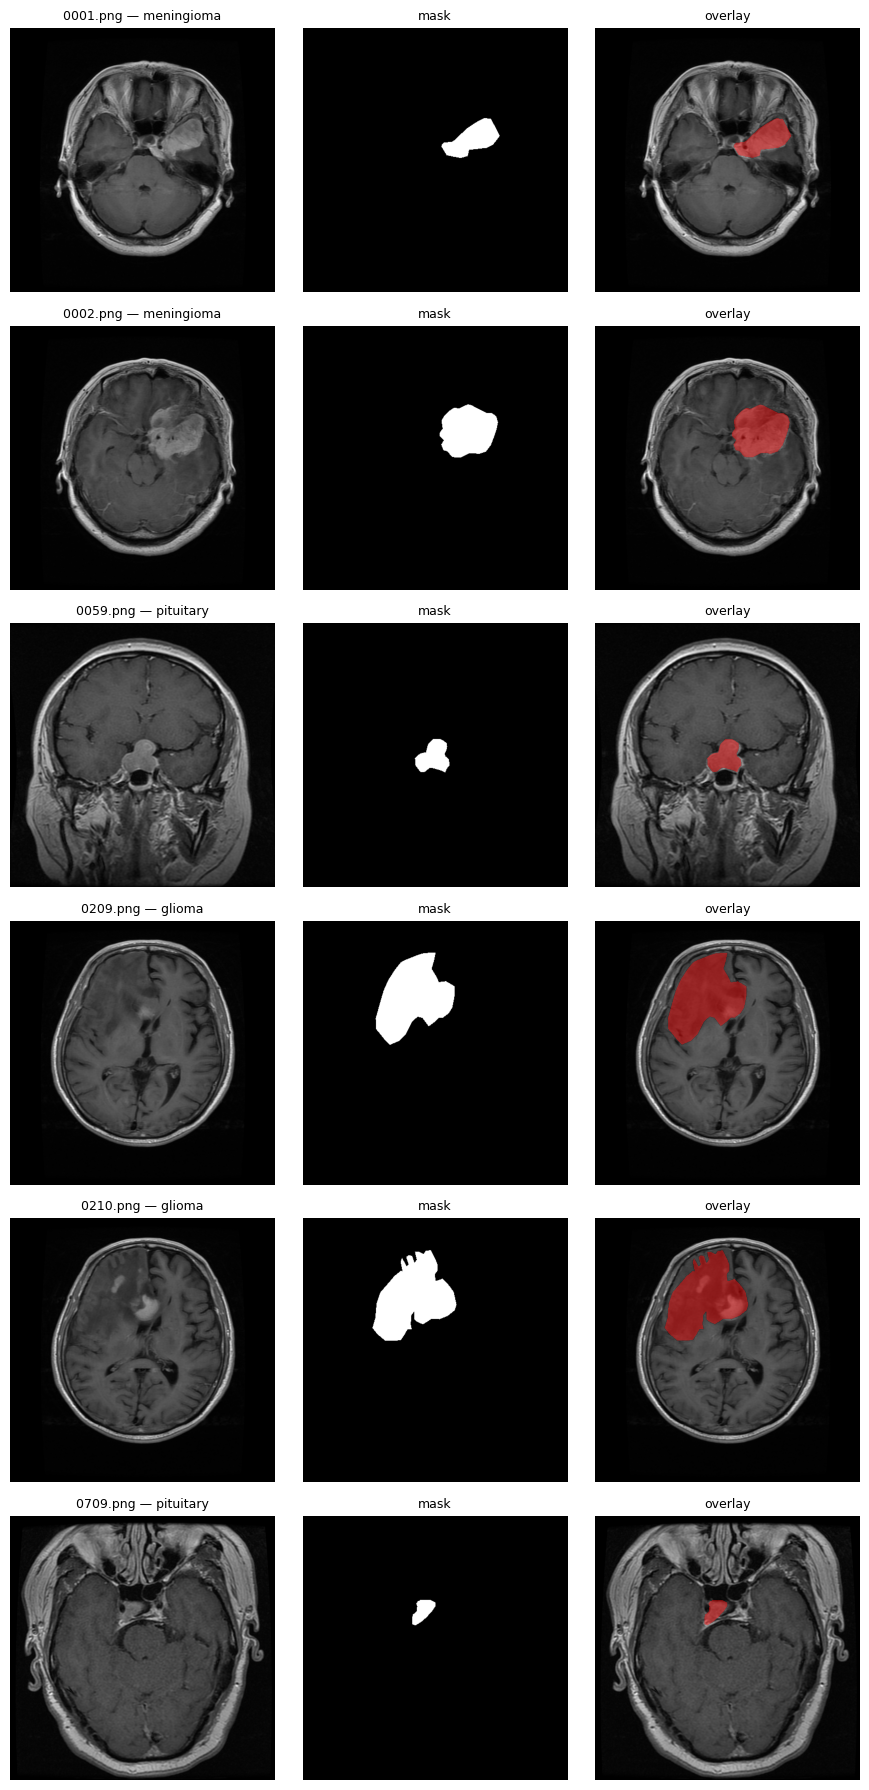

In [ ]:
import matplotlib.pyplot as plt

if HAS_TYPE:
    sample = meta.groupby("tumor_type", group_keys=False).head(2).reset_index(drop=True)
else:
    sample = meta.head(6).reset_index(drop=True)

fig, axes = plt.subplots(len(sample), 3, figsize=(9, 3 * len(sample)))

for ax_row, (_, r) in zip(axes, sample.iterrows()):
    img = cv2.imread(str(IMG_OUT / r["name"]), cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(str(MSK_OUT / r["name"]), cv2.IMREAD_GRAYSCALE)

    caption = f"{r['name']} — {r['tumor_type']}" if HAS_TYPE else r["name"]
    ax_row[0].imshow(img, cmap="gray")
    ax_row[0].set_title(caption, fontsize=9)
    ax_row[1].imshow(msk, cmap="gray")
    ax_row[1].set_title("mask", fontsize=9)
    ax_row[2].imshow(img, cmap="gray")
    ax_row[2].imshow(np.ma.masked_where(msk == 0, msk), cmap="autumn", alpha=0.45)
    ax_row[2].set_title("overlay", fontsize=9)
    for ax in ax_row:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# How much of each image is actually tumor? This drives the choice of loss.
fracs = []
for name in tqdm(meta["name"], desc="measuring"):
    m = cv2.imread(str(MSK_OUT / name), cv2.IMREAD_GRAYSCALE)
    fracs.append((m > 127).mean())

fracs = np.array(fracs)
print(f"tumor pixels per slice: mean {fracs.mean() * 100:.2f}%, median {np.median(fracs) * 100:.2f}%, max {fracs.max() * 100:.2f}%")

Tumor occupies about 2% of a typical slice. That is why the original uses Dice loss rather than
binary cross-entropy: a model that predicts "no tumor" everywhere scores ~98% pixel accuracy and is
completely useless, whereas its Dice score is ~0.

## 4. Data pipeline

The version below splits `(image, mask)` pairs together, so pairing holds by construction.

**The patient leakage caveat.** 233 patients contributed 3,064 slices, so adjacent slices from the
same scan are near-duplicates. A random slice-level split scatters those near-duplicates across
train and test, and the test score partly measures memorization. `SPLIT_BY_PATIENT = True` keeps
each patient entirely on one side. It reports a noticeably lower number — that is the honest one,
and it is the split to use if you plan to quote a result anywhere.

In [ ]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit


def load_dataset(path=DATA_DIR, split=SPLIT, seed=SEED, by_patient=SPLIT_BY_PATIENT):
    images = sorted(glob(os.path.join(str(path), "images", "*.png")))
    masks  = sorted(glob(os.path.join(str(path), "masks",  "*.png")))

    assert len(images) == len(masks), f"{len(images)} images vs {len(masks)} masks"
    assert all(os.path.basename(a) == os.path.basename(b) for a, b in zip(images, masks)), \
        "image/mask filenames are not aligned"

    pairs = np.array(list(zip(images, masks)))
    split_size = int(len(pairs) * split)

    if by_patient:
        if not HAS_PID:
            raise ValueError("SPLIT_BY_PATIENT=True needs a 'pid' column in metadata.csv.")
        pid = meta.set_index("name")["pid"]
        groups = np.array([pid[os.path.basename(p)] for p in pairs[:, 0]])

        gss = GroupShuffleSplit(n_splits=1, test_size=split, random_state=seed)
        rest_i, test_i = next(gss.split(pairs, groups=groups))
        gss2 = GroupShuffleSplit(n_splits=1, test_size=split, random_state=seed)
        tr_i, va_i = next(gss2.split(pairs[rest_i], groups=groups[rest_i]))
        train, valid, test = pairs[rest_i][tr_i], pairs[rest_i][va_i], pairs[test_i]
    else:
        # same nested split as the original, but on pairs
        train, valid = train_test_split(pairs, test_size=split_size, random_state=seed)
        train, test  = train_test_split(train, test_size=split_size, random_state=seed)

    unpack = lambda a: (list(a[:, 0]), list(a[:, 1]))
    return unpack(train), unpack(valid), unpack(test)


(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset()
print(f"Train: {len(train_x)}\nValid: {len(valid_x)}\nTest : {len(test_x)}")

In [ ]:
def read_image(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_COLOR)   # grayscale PNG -> 3 identical channels
    x = cv2.resize(x, (W, H))
    x = x / 255.0
    return x.astype(np.float32)


def read_mask(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (W, H))
    x = x / 255.0
    x = x.astype(np.float32)
    return np.expand_dims(x, axis=-1)        # (H, W, 1)


def tf_parse(x, y):
    def _parse(x, y):
        return read_image(x), read_mask(y)

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([H, W, 3])
    y.set_shape([H, W, 1])
    return x, y


def tf_dataset(X, Y, batch=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if shuffle:
        # The original never shuffles, so every epoch sees the same fixed order.
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)   # was serial
    ds = ds.batch(batch)
    return ds.prefetch(tf.data.AUTOTUNE)


train_dataset = tf_dataset(train_x, train_y, shuffle=True)
valid_dataset = tf_dataset(valid_x, valid_y)

xb, yb = next(iter(train_dataset))
print("batch:", xb.shape, yb.shape, "| image range", float(xb.numpy().min()), "-", float(xb.numpy().max()))

## 5. Metrics

One detail to be aware of when reading the training curves: this Dice is computed over the whole
flattened batch, not per image and then averaged. Batch-level Dice runs optimistically compared to
the per-image mean, because slices with large tumors dominate the sum. Section 8 reports the
per-image version, so the two numbers will not match — that is expected, not a bug.

In [ ]:
from tensorflow.keras import backend as K

smooth = 1e-15


def dice_coef(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

## 6. U-Net

The standard [U-Net](https://arxiv.org/abs/1505.04597): a four-stage
encoder (64→128→256→512 filters), a 1024-filter bottleneck, and a mirrored decoder where each stage
upsamples by transposed convolution and concatenates the matching encoder feature map. Those skip
connections carry the fine spatial detail that pooling throws away, which is what lets the output
have crisp boundaries.

Two differences from the 2015 paper: `padding="same"` everywhere, so the output is the same size as
the input rather than cropped, and batch normalization after every convolution. The head is a
single 1×1 convolution with sigmoid — one channel, tumor vs background.

In [ ]:
from tensorflow.keras.layers import (Activation, BatchNormalization, Concatenate, Conv2D,
                                     Conv2DTranspose, Input, MaxPool2D)
from tensorflow.keras.models import Model


def conv_block(inputs, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, 2, strides=2, padding="same")(inputs)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x


def build_unet(input_shape):
    inputs = Input(input_shape)

    # TODO: Build a U-Net with 3 encoder blocks with 64, 128, 256, and 512 filters
    # A 1024-filter bottleneck
    # 3 decoder blocks

    ...

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)
    return Model(inputs, outputs, name="UNET")


model = build_unet((H, W, 3))
print(f"{model.count_params():,} parameters")

In [ ]:
model.summary()

## 7. Training

The callbacks are the original set. One change: checkpoints are saved as
`.keras` rather than `.h5`, since `.h5` is the legacy format under Keras 3 and emits a deprecation
warning on every save.

`EarlyStopping` uses `restore_best_weights=False`, which means `model` in memory
ends up holding the *last* epoch's weights rather than the best. That is fine here because
evaluation reloads the checkpoint from disk — but it is worth knowing if you evaluate the in-memory
model directly.

In [ ]:
from tensorflow.keras.callbacks import (CSVLogger, EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

# TODO: Compile with dice_loss and dice_coef for metric
...

callbacks = [
    ModelCheckpoint(str(MODEL_PATH), verbose=1, save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger(str(CSV_PATH)),
    EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=False),
]

# TODO: Train the model
...

In [ ]:
log = pd.read_csv(CSV_PATH)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(log["epoch"], log["loss"], label="train")
a1.plot(log["epoch"], log["val_loss"], label="valid")
a1.set(xlabel="epoch", ylabel="Dice loss", title="Loss")
a1.legend(); a1.grid(alpha=.3)

a2.plot(log["epoch"], log["dice_coef"], label="train")
a2.plot(log["epoch"], log["val_dice_coef"], label="valid")
a2.set(xlabel="epoch", ylabel="Dice", title="Dice coefficient (batch-level)")
a2.legend(); a2.grid(alpha=.3)

plt.tight_layout(); plt.show()
print(f"best val_loss {log['val_loss'].min():.4f} at epoch {int(log.loc[log['val_loss'].idxmin(), 'epoch'])}")

## 8. Evaluation

Reloads the best checkpoint, predicts on the held-out test split, writes an
image / ground truth / prediction triptych per slice, and reports F1 (equivalently Dice), Jaccard
(IoU), recall and precision averaged **per image**.

In [ ]:
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score
from tensorflow.keras.utils import CustomObjectScope

with CustomObjectScope({"dice_coef": dice_coef, "dice_loss": dice_loss}):
    model = tf.keras.models.load_model(MODEL_PATH)

print("loaded", MODEL_PATH)

In [ ]:
def save_results(image, mask, y_pred, save_image_path):
    mask = np.expand_dims(mask, axis=-1)
    mask = np.concatenate([mask, mask, mask], axis=-1).astype(np.uint8)

    y_pred = np.expand_dims(y_pred, axis=-1)
    y_pred = (np.concatenate([y_pred, y_pred, y_pred], axis=-1) * 255).astype(np.uint8)

    # The original built this separator as float64, which made the whole
    # concatenation float64 and made OpenCV downcast on every write.
    line = np.full((H, 10, 3), 255, dtype=np.uint8)
    cat_images = np.concatenate([image.astype(np.uint8), line, mask, line, y_pred], axis=1)
    cv2.imwrite(str(save_image_path), cat_images)


SCORE = []
for x, y in tqdm(zip(test_x, test_y), total=len(test_y), desc="evaluating"):
    name = os.path.basename(x)

    image = cv2.imread(x, cv2.IMREAD_COLOR)
    image = cv2.resize(image, (W, H))
    xin = np.expand_dims(image / 255.0, axis=0)

    mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (W, H))

    y_pred = model.predict(xin, verbose=0)[0]
    y_pred = np.squeeze(y_pred, axis=-1)
    y_pred = (y_pred >= 0.5).astype(np.int32)

    save_results(image, mask, y_pred, RESULTS_DIR / name)

    mask_flat = (mask / 255.0 > 0.5).astype(np.int32).flatten()
    pred_flat = y_pred.flatten()

    SCORE.append([
        name,
        f1_score(mask_flat, pred_flat, labels=[0, 1], average="binary", zero_division=0),
        jaccard_score(mask_flat, pred_flat, labels=[0, 1], average="binary", zero_division=0),
        recall_score(mask_flat, pred_flat, labels=[0, 1], average="binary", zero_division=0),
        precision_score(mask_flat, pred_flat, labels=[0, 1], average="binary", zero_division=0),
    ])

df = pd.DataFrame(SCORE, columns=["Image", "F1", "Jaccard", "Recall", "Precision"])
df.to_csv(FILES_DIR / "score.csv", index=False)

s = df[["F1", "Jaccard", "Recall", "Precision"]].mean()
print(f"\nsplit: {'patient-wise' if SPLIT_BY_PATIENT else 'random slice-level'}  (n={len(df)})")
print(f"F1 (Dice): {s['F1']:0.5f}")
print(f"Jaccard:   {s['Jaccard']:0.5f}")
print(f"Recall:    {s['Recall']:0.5f}")
print(f"Precision: {s['Precision']:0.5f}")

In [ ]:
# Per tumor type — pituitary tumors are usually easiest, gliomas hardest.
if HAS_TYPE:
    by_type = df.merge(meta, left_on="Image", right_on="name")
    print(by_type.groupby("tumor_type")[["F1", "Jaccard"]].agg(["mean", "count"]).round(4).to_string())
else:
    print("No 'tumor_type' column in metadata.csv — skipping the per-type breakdown.")

In [ ]:
# Best and worst cases: image | ground truth | prediction
order = df["F1"].sort_values()
picks = list(order.tail(3).index) + list(order.head(3).index)
titles = ["best"] * 3 + ["worst"] * 3

fig, axes = plt.subplots(len(picks), 1, figsize=(10, 2.6 * len(picks)))
for ax, i, t in zip(axes, picks, titles):
    trip = cv2.imread(str(RESULTS_DIR / df.loc[i, "Image"]))
    ax.imshow(cv2.cvtColor(trip, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{t} — {df.loc[i, 'Image']}  F1={df.loc[i, 'F1']:.3f}", fontsize=9)
    ax.axis("off")

plt.tight_layout(); plt.show()

The worst cases are usually one of two failure modes: a small tumor missed entirely (F1 = 0, which
drags the per-image mean down hard) or a slice at the edge of a scan where the tumor is barely a few
pixels. Both are artifacts of scoring every slice equally regardless of tumor size.

---

## Where to go next

- **Augmentation.** There is none here. Flips, small rotations and elastic deformations are the
  standard win on this dataset and cost nothing at inference time.
- **Combined loss.** `dice_loss + binary_crossentropy` usually converges more stably than Dice alone,
  which can be flat early on when predictions barely overlap the target.
- **Feed the tumor type in.** `cjdata.label` is sitting unused in the metadata CSV. Adding a
  classification head turns this into a multi-task model, which often helps segmentation too.
- **Other architectures.** Try ResUNet and DeepLabV3+. Swapping in a
  pretrained encoder (ResNet, EfficientNet) is usually the single biggest improvement over a
  from-scratch U-Net on a dataset this size.